Importing libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


Uploading dataset

In [ ]:
df = pd.read_excel("sales_analysis.csv.xlsx")

In [ ]:
df.shape
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 13 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       119143 non-null  object        
 1   customer_unique_id             119143 non-null  object        
 2   customer_city                  119143 non-null  object        
 3   customer_state                 119143 non-null  object        
 4   order_status                   119143 non-null  object        
 5   order_purchase_timestamp       119143 non-null  datetime64[ns]
 6   order_approved_at              118966 non-null  datetime64[ns]
 7   price                          118310 non-null  float64       
 8   freight_value                  118310 non-null  float64       
 9   product_category_name_english  116576 non-null  object        
 10  payment_type                   119140 non-null  object        
 11  

,order_purchase_timestamp,order_approved_at,price,freight_value,payment_value,review_score
count,119143,118966,118310.000000,118310.000000,119140.000000,118146.000000
mean,2017-12-29 18:35:43.588293376,2017-12-30 04:48:51.840694016,120.646603,20.032387,172.735135,4.015582
min,2016-09-04 21:15:00,2016-09-15 12:16:00,0.850000,0.000000,0.000000,1.000000
25%,2017-09-10 20:15:00,2017-09-11 15:50:00,39.900000,13.080000,60.850000,4.000000
50%,2018-01-17 11:59:00,2018-01-17 16:49:00,74.900000,16.280000,108.160000,5.000000
75%,2018-05-03 13:18:00,2018-05-03 16:56:00,134.900000,21.180000,189.240000,5.000000
max,2018-10-17 17:30:00,2018-09-03 17:40:00,6735.000000,409.680000,13664.080000,5.000000
std,NaN,NaN,184.109691,15.836850,267.776077,1.400436


Data cleaning

In [ ]:
# Missing values
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

# Missing value percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage[missing_percentage > 0].round(2)

# Duplicate rows
df.duplicated().sum()
df = df.drop_duplicates()
df.shape

(106613, 13)

Data type conversion

In [ ]:
date_columns = ['order_purchase_timestamp', 'order_approved_at']

for col in date_columns:
    df[col] = pd.to_datetime(df[col])

print("Data types after conversion:")
print(df[date_columns].dtypes)

Data types after conversion:
order_purchase_timestamp    datetime64[ns]
order_approved_at           datetime64[ns]
dtype: object


Handling missing values

In [ ]:
# Remove rows with missing payment information
df = df.dropna(subset=['payment_type', 'payment_value'])

# Replace missing product categories with Unknown
df['product_category_name_english'] = df['product_category_name_english'].fillna('Unknown')

# Check why price values are missing
df[df['price'].isnull()]['order_status'].value_counts()

# Remove rows with missing price or freight values
df = df.dropna(subset=['price', 'freight_value'])

# Keep missing review scores as they represent customers who did not submit a review

# Check remaining missing values
remaining_missing = df.isnull().sum()
remaining_missing[remaining_missing > 0]

,0
order_approved_at,14
review_score,813


Feature engineering

In [ ]:
df['Year'] = df['order_purchase_timestamp'].dt.year
df['Month'] = df['order_purchase_timestamp'].dt.month
df['Month Name'] = df['order_purchase_timestamp'].dt.month_name()
df['Day of Week'] = df['order_purchase_timestamp'].dt.day_name()

# Order value including freight — useful for AOV-style questions
df['order_total_value'] = df['price'] + df['freight_value']

print("New columns added:", ['Year', 'Month', 'Month Name', 'Day of Week', 'order_total_value'])
display(df[['order_purchase_timestamp', 'Year', 'Month', 'Month Name', 'Day of Week']].head())

New columns added: ['Year', 'Month', 'Month Name', 'Day of Week', 'order_total_value']


,order_purchase_timestamp,Year,Month,Month Name,Day of Week
0,2018-08-08 10:00:00,2018,8,August,Wednesday
1,2018-03-24 22:16:00,2018,3,March,Saturday
2,2018-02-13 22:10:00,2018,2,February,Tuesday
4,2018-08-14 20:43:00,2018,8,August,Tuesday
5,2018-04-25 09:10:00,2018,4,April,Wednesday


EDA

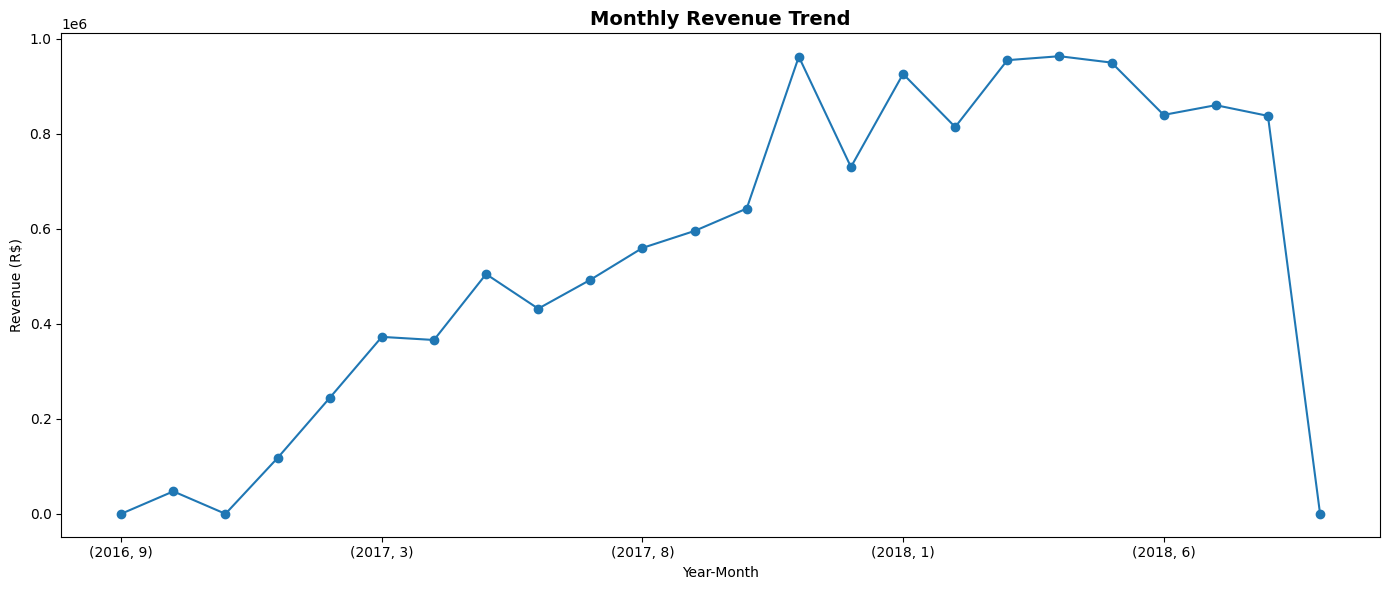

In [ ]:
monthly_rev = df.groupby(['Year', 'Month'])['price'].sum()

plt.figure(figsize=(14, 6))
monthly_rev.plot(kind='line', marker='o')
plt.title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
plt.xlabel('Year-Month')
plt.ylabel('Revenue (R$)')
plt.tight_layout()
plt.show()

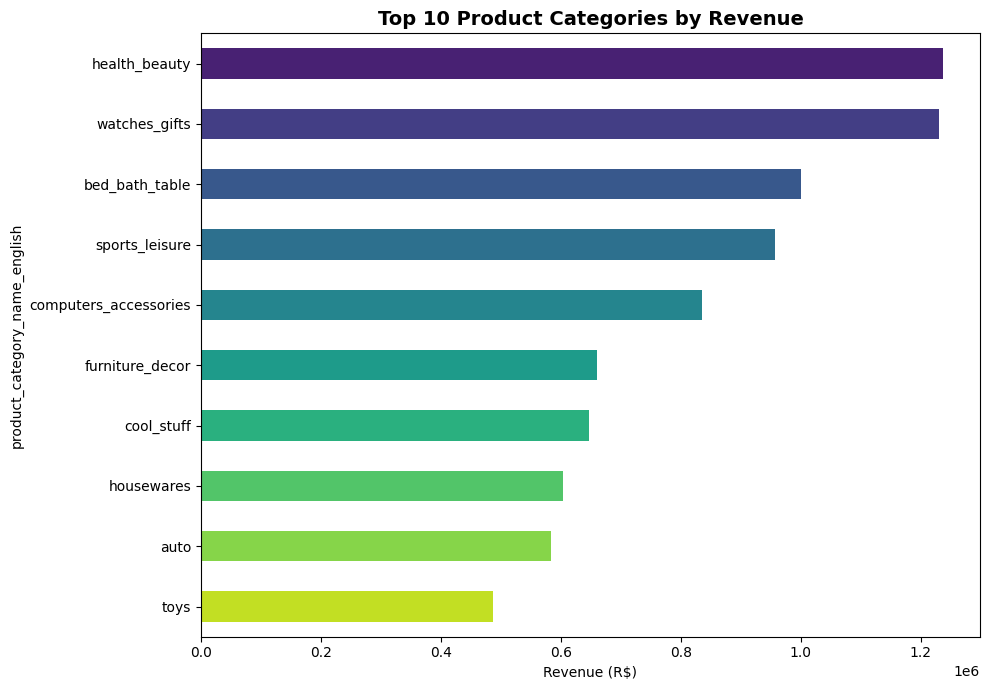

In [ ]:
top_categories = df.groupby('product_category_name_english')['price'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 7))
top_categories.plot(kind='barh', color=sns.color_palette('viridis', 10))
plt.title('Top 10 Product Categories by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Revenue (R$)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

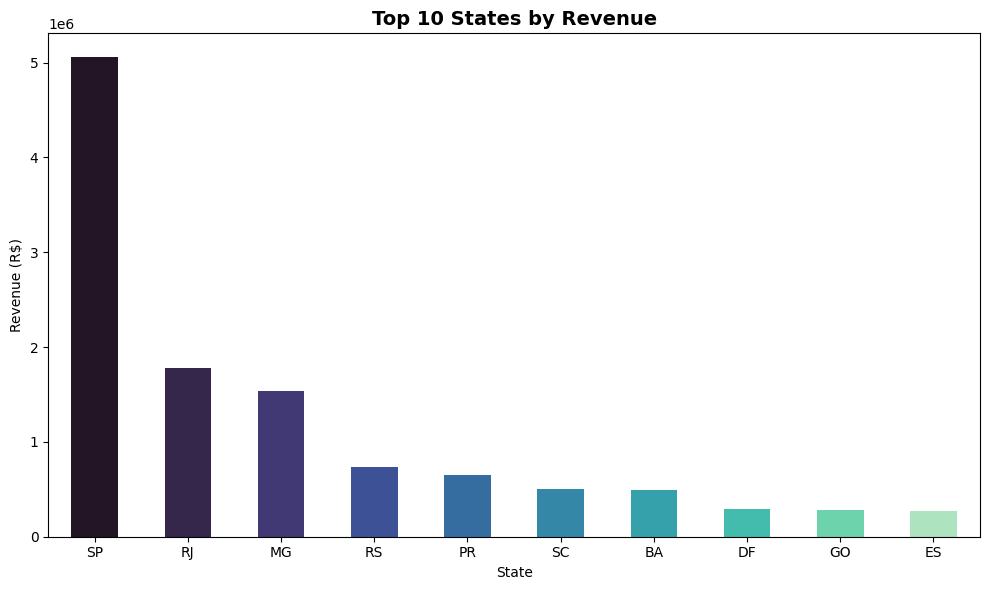

In [ ]:
top_states = df.groupby('customer_state')['price'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_states.plot(kind='bar', color=sns.color_palette('mako', 10))
plt.title('Top 10 States by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Revenue (R$)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

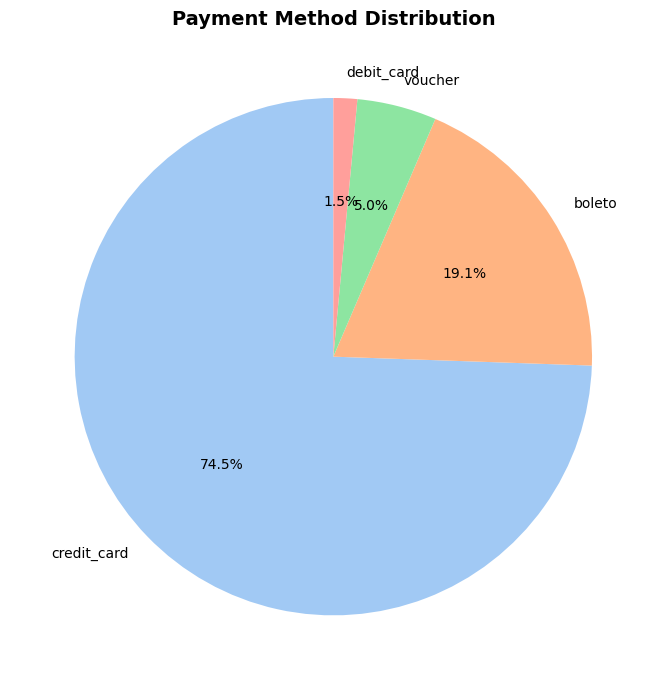

In [ ]:
payment_dist = df['payment_type'].value_counts(normalize=True).mul(100)

plt.figure(figsize=(7, 7))
plt.pie(payment_dist, labels=payment_dist.index, autopct='%1.1f%%',
        colors=sns.color_palette('pastel'), startangle=90)
plt.title('Payment Method Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

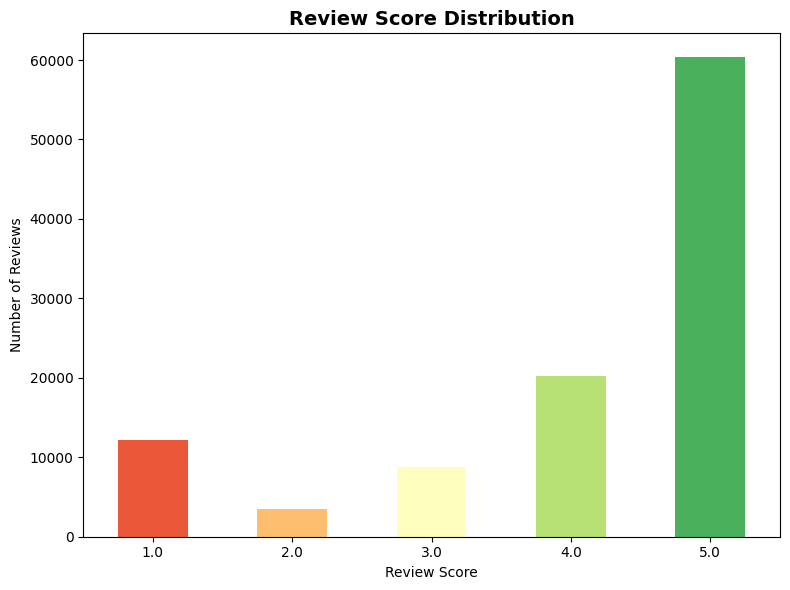

In [ ]:
review_dist = df['review_score'].dropna().value_counts().sort_index()

plt.figure(figsize=(8, 6))
review_dist.plot(kind='bar', color=sns.color_palette('RdYlGn', 5))
plt.title('Review Score Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Review Score')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

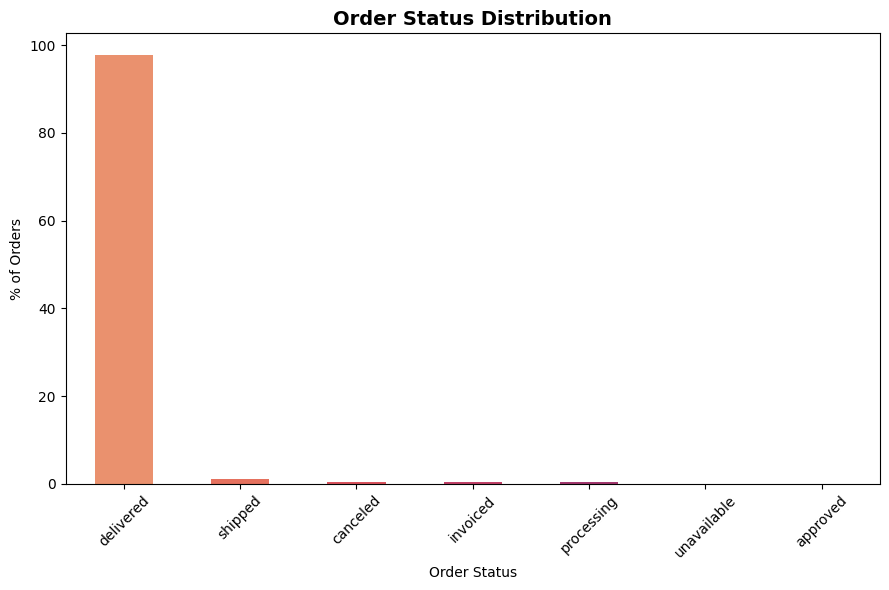

In [ ]:
status_dist = df['order_status'].value_counts(normalize=True).mul(100)

plt.figure(figsize=(9, 6))
status_dist.plot(kind='bar', color=sns.color_palette('flare', len(status_dist)))
plt.title('Order Status Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Order Status')
plt.ylabel('% of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

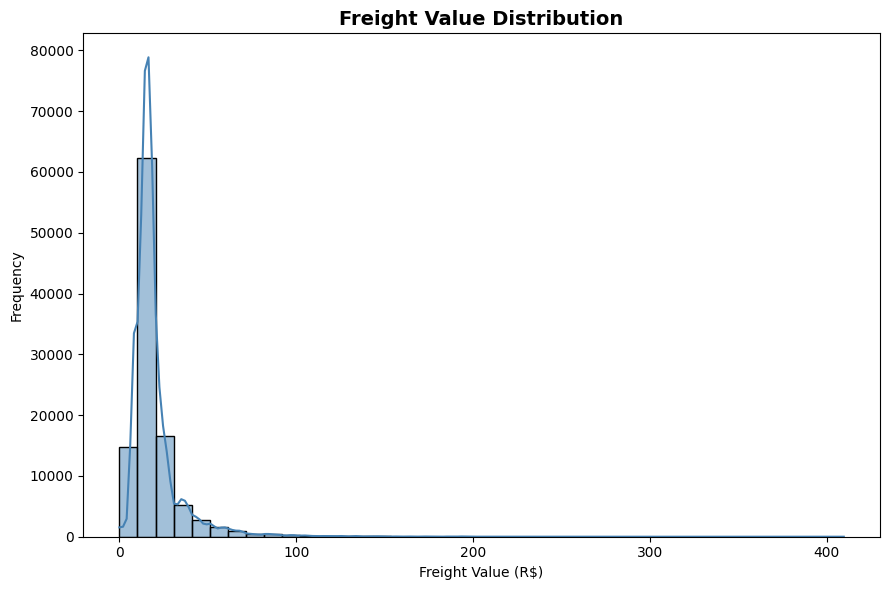

In [ ]:
plt.figure(figsize=(9, 6))
sns.histplot(df['freight_value'], bins=40, kde=True, color='steelblue')
plt.title('Freight Value Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Freight Value (R$)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

avg_price = df['price'].mean()
avg_freight = df['freight_value'].mean()
freight_pct = (df['freight_value'] / df['price']).mean() * 100

saving clean dataset

In [ ]:
df.to_csv('sales_analysis_cleaned.csv', index=False)
print("Cleaned dataset exported: sales_analysis_cleaned.csv")
print("Final shape:", df.shape)

Cleaned dataset exported: sales_analysis_cleaned.csv
Final shape: (105800, 18)
